<div class="notebook-nav"><a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey/pretraining.ipynb">&larr; Previous: 4. Pretraining: Learning the Data Distribution</a> &middot; <a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey.ipynb">Journey home</a></div>

# 5. Strategy A: Manufacture a Density

Chapter 4 defined pretraining and separated three strategies for making its distribution-matching
objective computable. Strategy A takes the most direct route: change the model until its own density
can be used.

## 1. The Strategy A bargain

Forward KL gives the familiar pretraining objective

$$
\mathrm{KL}(P\,\|\,Q_\theta)
=
\mathbb{E}_{x\sim P}[\log p(x)]
-
\mathbb{E}_{x\sim P}[\log q_\theta(x)].
\tag{5.1}
$$

The first term is constant in $\theta$, so training only needs target samples and a differentiable
model log-density $\log q_\theta(x)$. The data provide the samples. A general pushforward does not
provide the density.

Strategy A constrains or augments the model until that missing operation becomes available:

| Method | $D$ in its computable form | Constraint used | The bill |
|:---|:---|:---|:---|
| **A1. Normalizing flow** | exact maximum likelihood | invertible map with tractable Jacobian | cannot freely tear or merge the source |
| **A2. Variational autoencoder** | ELBO lower bound | latent-variable model plus encoder | model-dependent gap and averaging pressure |
| **A3. Autoregressive model** | exact chain-rule likelihood | ordered conditional factorization | sequential generation and compounding errors |

The density is exact for A1 and A3. A2 instead constructs a computable lower bound on the
log-density. All three pursue the same endpoint goal while paying different structural prices for
making likelihood usable.

## 2. The shared pretraining example

We use Chapter 4's lightweight two-dimensional example: a standard-Gaussian source and an
eight-component Gaussian-ring target available through a finite sample.

Every method will be judged by the same two readings:

- **energy distance**, a sample-only distribution comparison from Chapter 2;
- **mode coverage**, the number of ring components receiving at least two percent of the generated mass.

The code cell contains the complete shared runtime, so this notebook runs independently in Colab.

In [1]:
from __future__ import annotations
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


N_MODES = 8
RING_RADIUS = 4.0
MODE_STD = 0.30
EVAL_N = 3000

angles = torch.arange(N_MODES) * (2 * math.pi / N_MODES)
MODE_CENTERS = torch.stack(
    [RING_RADIUS * torch.cos(angles), RING_RADIUS * torch.sin(angles)],
    dim=1,
)
MODE_COLORS = [plt.get_cmap("tab10")(k) for k in range(N_MODES)]


def sample_ring(n, weights=None):
    '''Draw samples from the eight-component Gaussian ring.'''
    if weights is None:
        component = torch.randint(0, N_MODES, (n,))
    else:
        component = torch.multinomial(weights, n, replacement=True)
    return MODE_CENTERS[component] + MODE_STD * torch.randn(n, 2)


def sample_source(n):
    '''Draw samples from the two-dimensional standard Gaussian source.'''
    return torch.randn(n, 2)


def assign_modes(x):
    '''Return the nearest ring-mode index for each sample.'''
    return torch.cdist(x, MODE_CENTERS).argmin(1)


def plot_samples(ax, x, title="", color="#1d4ed8", by_mode=False):
    '''Plot a two-dimensional sample cloud on the shared canvas.'''
    x = x.detach().cpu()
    colors = (
        [MODE_COLORS[k] for k in assign_modes(x).tolist()]
        if by_mode
        else color
    )
    ax.scatter(
        x[:, 0],
        x[:, 1],
        s=5,
        alpha=0.35,
        c=colors,
        edgecolors="none",
    )
    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(-6.5, 6.5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])


DATA = sample_ring(EVAL_N)

import torch.nn as nn
from tqdm import tqdm


def mode_histogram(x):
    '''Return the sample fraction assigned to each ring mode.'''
    return torch.bincount(assign_modes(x), minlength=N_MODES).float() / len(x)


def modes_hit(x, threshold=0.02):
    '''Count modes containing more than threshold of the sample mass.'''
    return int((mode_histogram(x) > threshold).sum())


def energy_distance(x, y):
    '''Compute the empirical energy distance between two sample batches.'''
    mean_distance = lambda a, b: torch.cdist(a, b).mean()
    return (
        2 * mean_distance(x, y)
        - mean_distance(x, x)
        - mean_distance(y, y)
    ).item()


def mlp(inp, out, hidden=128, depth=3, activation=nn.SiLU):
    '''Build a small multilayer perceptron.'''
    layers = [nn.Linear(inp, hidden), activation()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(hidden, hidden), activation()])
    return nn.Sequential(*layers, nn.Linear(hidden, out))

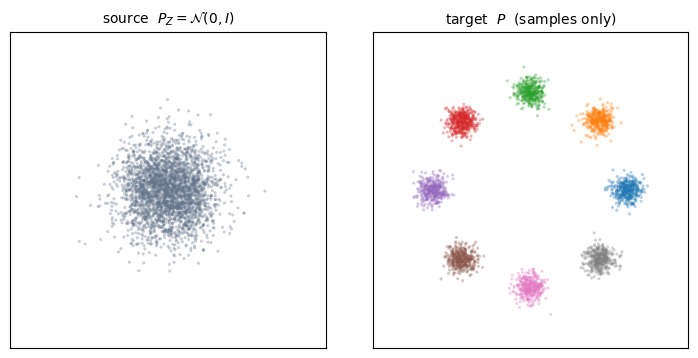

In [2]:
DENSITY_RUNS = {}


def record_run(key, samples, sample_steps):
    '''Measure and retain one density model's generated samples.'''
    result = {
        "samples": samples.detach(),
        "energy": energy_distance(samples, DATA),
        "modes": modes_hit(samples),
        "sample_steps": sample_steps,
    }
    DENSITY_RUNS[key] = result
    print(
        f"{key:18s}  ED={result['energy']:.4f}  "
        f"modes={result['modes']}/8  sample steps={sample_steps}"
    )


def show_run(key, label):
    '''Plot one trained model beside the shared target.'''
    result = DENSITY_RUNS[key]
    fig, ax = plt.subplots(1, 2, figsize=(7.4, 3.6))
    title = f"{label}\nED={result['energy']:.3f}   modes={result['modes']}/8"
    plot_samples(ax[0], result["samples"], title, by_mode=True)
    plot_samples(ax[1], DATA, "target", color="#b45309", by_mode=True)
    plt.tight_layout()
    plt.show()


fig, ax = plt.subplots(1, 2, figsize=(7.4, 3.6))
plot_samples(ax[0], sample_source(EVAL_N), r"source  $P_Z=\mathcal{N}(0,I)$", color="#64748b")
plot_samples(ax[1], DATA, "target  $P$  (samples only)", color="#b45309", by_mode=True)
plt.tight_layout()
plt.show()

## 3. A1: normalizing flow

A [normalizing flow](https://arxiv.org/abs/1505.05770) starts from the change-of-variables result in
Chapter 1. If $G_\theta$ is invertible and its Jacobian determinant is tractable, then

$$
\log q_\theta(x)
=
\log p_Z\!\left(G_\theta^{-1}(x)\right)
+
\log\left|
\det\frac{\partial G_\theta^{-1}}{\partial x}
\right|.
\tag{5.2}
$$

[RealNVP](https://arxiv.org/abs/1605.08803) satisfies that requirement with **coupling layers**. Each
layer leaves one coordinate unchanged and rescales and shifts the other as a function of it. Write
$x=(x_a,x_b)$. Two small neural networks read the unchanged coordinate: $s_\theta(x_a)$ produces a
log-scale and $t_\theta(x_a)$ produces a translation. One data-to-latent coupling is

$$
u_a=x_a,
\qquad
u_b=x_b\exp\!\big(s_\theta(x_a)\big)+t_\theta(x_a).
\tag{5.3}
$$

The first coordinate passes through unchanged, so $x_a=u_a$ is already known when we invert the
second equation:

$$
x_a=u_a,
\qquad
x_b=
\left[u_b-t_\theta(u_a)\right]
\exp\!\big(-s_\theta(u_a)\big).
\tag{5.4}
$$

No inverse neural network is needed. The same scale and shift networks are evaluated at the unchanged
coordinate. The Jacobian is triangular,

$$
\frac{\partial u}{\partial x}
=
\begin{bmatrix}
1 & 0\\
\dfrac{\partial u_b}{\partial x_a} & \exp(s_\theta(x_a))
\end{bmatrix},
\qquad
\log\left|\det\frac{\partial u}{\partial x}\right|
=s_\theta(x_a).
\tag{5.5}
$$

The exponential scale is always positive, so every input has exactly one output and the inverse above
always exists. Alternating which coordinate stays fixed lets both coordinates change. A stack of
invertible couplings remains invertible; sampling simply applies their inverses in reverse order.

The resulting likelihood is exact. The restriction is architectural: every layer and the full
generator must remain invertible.

Related flow architectures include [Glow](https://arxiv.org/abs/1807.03039),
[MAF](https://arxiv.org/abs/1705.07057), [IAF](https://arxiv.org/abs/1606.04934), and continuous
[FFJORD](https://arxiv.org/abs/1810.01367).

A1 normalizing flow: 100%|██████████| 4000/4000 [00:16<00:00, 247.65it/s]


normalizing flow    ED=0.0172  modes=8/8  sample steps=1


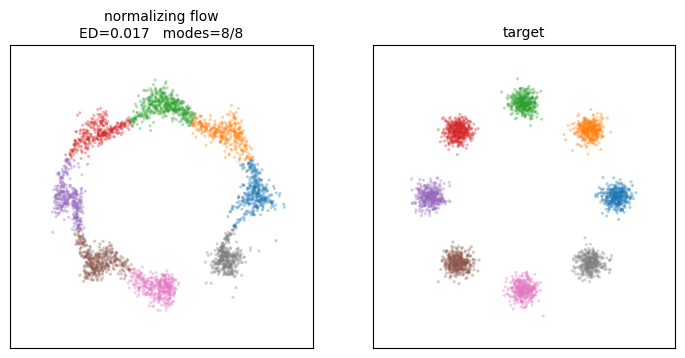

In [3]:
class Coupling(nn.Module):
    '''RealNVP affine coupling for two-dimensional data.'''
    def __init__(self, flip, hidden=64):
        super().__init__()
        self.flip = flip
        self.net = mlp(1, 2, hidden, depth=2)

    def _split(self, x):
        if self.flip:
            return x[:, 1:2], x[:, 0:1]
        return x[:, 0:1], x[:, 1:2]

    def _join(self, fixed, changed):
        if self.flip:
            return torch.cat([changed, fixed], dim=1)
        return torch.cat([fixed, changed], dim=1)

    def forward(self, x):
        '''Map data to latent space and return log absolute Jacobian determinant.'''
        fixed, changed = self._split(x)
        scale_shift = self.net(fixed)
        log_scale = scale_shift[:, :1].tanh() * 2.0
        shift = scale_shift[:, 1:]
        latent = changed * torch.exp(log_scale) + shift
        return self._join(fixed, latent), log_scale.squeeze(1)

    def inverse(self, z):
        '''Map latent points back to data space.'''
        fixed, changed = self._split(z)
        scale_shift = self.net(fixed)
        log_scale = scale_shift[:, :1].tanh() * 2.0
        shift = scale_shift[:, 1:]
        data = (changed - shift) * torch.exp(-log_scale)
        return self._join(fixed, data)


class RealNVP(nn.Module):
    def __init__(self, n_layers=8):
        super().__init__()
        self.layers = nn.ModuleList([Coupling(i % 2) for i in range(n_layers)])

    def log_prob(self, x):
        log_det = x.new_zeros(len(x))
        for layer in self.layers:
            x, layer_log_det = layer(x)
            log_det = log_det + layer_log_det
        base_log_prob = -0.5 * x.square().sum(1) - math.log(2 * math.pi)
        return base_log_prob + log_det

    @torch.no_grad()
    def sample(self, n):
        x = sample_source(n)
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x


torch.manual_seed(11)
flow = RealNVP()
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
for _ in tqdm(range(4000), desc="A1 normalizing flow"):
    loss = -flow.log_prob(sample_ring(512)).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

record_run("normalizing flow", flow.sample(EVAL_N), sample_steps=1)
show_run("normalizing flow", "normalizing flow")

### Reading the trained flow

The flow reaches all eight modes, so this is not mode collapse. But each compact target cluster is
stretched into an arc, and thin bridges remain between neighboring modes. Exact likelihood makes the
training objective exact; it does not remove the finite architecture's invertibility constraint.

> **Why the ring comes out frayed.** An invertible map can stretch and fold the Gaussian source, but
> it cannot independently place mass in each mode without also controlling what happens between
> them. In this finite eight-layer RealNVP, alternating one-coordinate couplings and bounded
> log-scales limit how sharply the map can expand low-density regions while compressing the modes.
> Forward KL would also rather retain a thin bridge than abandon a target mode. The observed arcs and
> bridges therefore reflect the combination of invertibility, limited model expressiveness, bounded
> scaling, and optimization—not a proof that every normalizing flow must produce this distortion.

The visible bill is therefore **connected excess mass between modes**.

## 4. A2: variational autoencoder

A [variational autoencoder](https://arxiv.org/abs/1312.6114) introduces a latent variable $z$ and a
conditional model $p_\theta(x\mid z)$, called the **decoder**, which maps a latent code to a
distribution over data points. Unlike a normalizing flow, this map does not need to be invertible.
Draw

$$
z\sim p(z)=\mathcal N(0,I),
\qquad
x\sim p_\theta(x\mid z).
$$

The model density is the continuous mixture

$$
q_\theta(x)
=
\int p_\theta(x\mid z)\,p(z)\,dz.
\tag{5.6}
$$

Sampling is easy: draw one $z$ and decode it. Density evaluation is hard because the integral must
consider every latent code that could have produced $x$.

### Replace the integral by a lower bound

Introduce an encoder $q_\phi(z\mid x)$ that proposes plausible codes for each data point. The
intractable log-density splits into two exact pieces:

$$
\log q_\theta(x)
=
\underbrace{
\mathbb E_{q_\phi(z\mid x)}
\left[
\log\frac{p_\theta(x\mid z)p(z)}{q_\phi(z\mid x)}
\right]
}_{\mathrm{ELBO}(x)}
+
\underbrace{
\mathrm{KL}\!\left(q_\phi(z\mid x)\,\|\,p_\theta(z\mid x)\right)
}_{\ge 0}.
\tag{5.7}
$$

Dropping the nonnegative second term gives the evidence lower bound. Regrouping it produces the two
terms used in the code:

$$
\mathrm{ELBO}(x)
=
\underbrace{
\mathbb E_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)]
}_{\text{encode }x\text{ to }z,\ \text{then decode back to }x}
-
\underbrace{
\mathrm{KL}\!\left(q_\phi(z\mid x)\,\|\,p(z)\right)
}_{\text{keep codes near the prior}}.
\tag{5.8}
$$

### Differentiate through the latent draw

Sampling $z\sim q_\phi(z\mid x)$ hides the encoder parameters inside a random operation. For a Gaussian
encoder, write the same draw as

$$
z
=
\mu_\phi(x)+\sigma_\phi(x)\odot\epsilon,
\qquad
\epsilon\sim\mathcal N(0,I).
\tag{5.9}
$$

The randomness now lives in parameter-free $\epsilon$, while every occurrence of $\phi$ sits in an
ordinary differentiable expression. This is the **reparameterization** construction.

A2 variational autoencoder: 100%|██████████| 5000/5000 [00:08<00:00, 608.33it/s]


VAE                 ED=0.0518  modes=8/8  sample steps=1


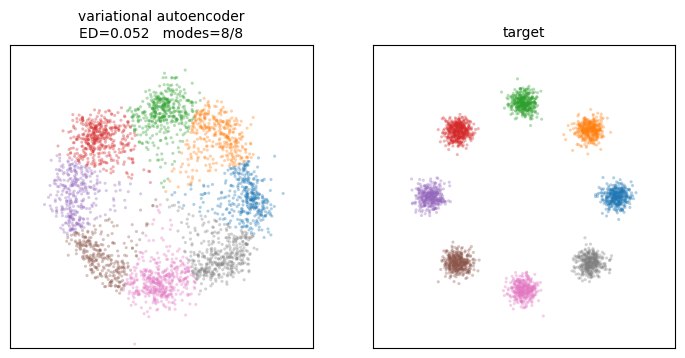

In [4]:
RECON_VARIANCE = 0.05


class VAE(nn.Module):
    def __init__(self, latent_dim=2, hidden=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = mlp(2, 2 * latent_dim, hidden, depth=2)
        self.decoder = mlp(latent_dim, 2, hidden, depth=2)

    def forward(self, x):
        encoded = self.encoder(x)
        mean = encoded[:, :self.latent_dim]
        log_variance = encoded[:, self.latent_dim:].clamp(-6, 2)
        noise = torch.randn_like(mean)
        z = mean + noise * torch.exp(0.5 * log_variance)
        return self.decoder(z), mean, log_variance

    @torch.no_grad()
    def sample(self, n):
        mean = self.decoder(torch.randn(n, self.latent_dim))
        return mean + math.sqrt(RECON_VARIANCE) * torch.randn_like(mean)

torch.manual_seed(22)
torch.manual_seed(22)
vae = VAE()
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
for _ in tqdm(range(5000), desc="A2 variational autoencoder"):
    x = sample_ring(512)
    reconstruction, mean, log_variance = vae(x)
    reconstruction_loss = reconstruction.sub(x).square().sum(1) / (2 * RECON_VARIANCE)
    prior_kl = 0.5 * (
        mean.square() + torch.exp(log_variance) - 1 - log_variance
    ).sum(1)
    loss = (reconstruction_loss + prior_kl).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

record_run("VAE", vae.sample(EVAL_N), sample_steps=1)
show_run("VAE", "variational autoencoder")

### Reading the trained VAE

The VAE also reaches all eight modes, but its mass is much more diffuse than the target. Neighboring
clusters overlap, and substantial probability fills the interior of the ring. The failure is
**softening**, not mode dropping.

The ELBO identity explains the first cost. Its gap from $\log q_\theta(x)$ moves with the model, so
maximizing the bound also favors models whose posterior a simple Gaussian encoder can approximate.
The two ELBO terms create another compromise: the reconstruction term asks each latent code to retain
enough information about its input, while the KL term pushes the codes toward one shared Gaussian
prior. Codes for different examples can therefore overlap, and a Gaussian decoder averages ambiguous
destinations and spreads probability around its predicted mean.

A richer posterior or decoder can reduce these effects, but then inference and density approximation
become more expensive. Related latent-variable models include
[IWAE](https://arxiv.org/abs/1509.00519) and [VQ-VAE](https://arxiv.org/abs/1711.00937).

## 5. A3: autoregressive model

An [autoregressive model](https://arxiv.org/abs/1605.02226) factorizes the joint density by the chain
rule. In two dimensions,

$$
q_\theta(x_1,x_2)
=
q_\theta(x_1)\,
q_\theta(x_2\mid x_1),
\tag{5.10}
$$

so

$$
\log q_\theta(x_1,x_2)
=
\log q_\theta(x_1)
+
\log q_\theta(x_2\mid x_1).
$$

The ring makes both one-dimensional factors multimodal: $q(x_1)$ has several peaks, and for many
values of $x_1$, $q(x_2\mid x_1)$ has an upper and a lower branch. A single Gaussian would average
those possibilities, so we use a conditional Gaussian mixture:

$$
q_\theta(x_j\mid x_{<j})
=
\sum_{k=1}^{K}
\pi_{\theta,k}(x_{<j})\,
\mathcal N\!\left(
x_j;\,
\mu_{\theta,k}(x_{<j}),
\sigma_{\theta,k}^2(x_{<j})
\right).
\tag{5.11}
$$

For $x_1$, the mixture parameters are learned directly. For $x_2$, a small neural network reads
$x_1$ and produces the weights, means, and scales. We use $K=12$ components. This is a natural choice
for our continuous example: the likelihood is exact, sampling means choosing one component and
drawing one Gaussian value, and no coordinate discretization is needed.

The cost moves to sampling. We must draw $x_1$ before evaluating the distribution of $x_2$. In $d$
dimensions that becomes $d$ strictly sequential predictions, each conditioned on every coordinate
already generated.

> *The two-dimensional setting flatters A3.* Here $d=2$, so the whole sample costs only two network calls and each
> conditional depends on at most one scalar. For a $1024\times1024$ RGB image, coordinate-wise
> generation would require more than three million sequential draws. Errors also compound because
> training conditions on true prefixes while generation conditions on the model's own outputs.
> High-dimensional conditionals require substantial history-reading machinery, and the coordinate
> order itself becomes a modeling choice. The same sequential bottleneck appears in autoregressive
> language models, motivating techniques such as
> [speculative decoding](https://xingmei.io/notes/building_dspark.html).

Related autoregressive architectures include [PixelCNN](https://arxiv.org/abs/1601.06759),
[WaveNet](https://arxiv.org/abs/1609.03499), and [MADE](https://arxiv.org/abs/1502.03509).

A3 autoregressive model: 100%|██████████| 5000/5000 [00:06<00:00, 804.23it/s]


autoregressive      ED=0.0072  modes=8/8  sample steps=2


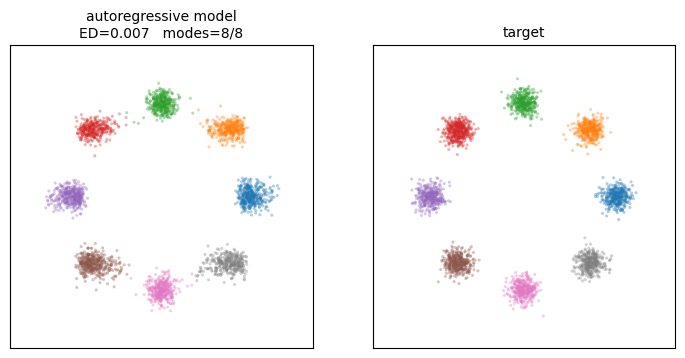

In [5]:
class GaussianMixture1D(nn.Module):
    '''A one-dimensional Gaussian mixture, optionally conditioned on another value.'''
    def __init__(self, condition_dim, n_components=12, hidden=64):
        super().__init__()
        self.condition_dim = condition_dim
        self.n_components = n_components
        if condition_dim == 0:
            self.unconditional = nn.Parameter(torch.randn(3 * n_components) * 0.1)
        else:
            self.network = mlp(condition_dim, 3 * n_components, hidden, depth=2)

    def parameters_at(self, condition, n):
        if self.condition_dim == 0:
            raw = self.unconditional.expand(n, -1)
        else:
            raw = self.network(condition)
        k = self.n_components
        logits = raw[:, :k].log_softmax(1)
        means = raw[:, k:2 * k]
        log_scales = raw[:, 2 * k:].clamp(-4, 2)
        return logits, means, log_scales

    def log_prob(self, target, condition, n):
        log_weights, means, log_scales = self.parameters_at(condition, n)
        component_log_prob = (
            -0.5 * ((target - means) / torch.exp(log_scales)).square()
            - log_scales
            - 0.5 * math.log(2 * math.pi)
        )
        return torch.logsumexp(log_weights + component_log_prob, dim=1)

    def sample(self, condition, n):
        log_weights, means, log_scales = self.parameters_at(condition, n)
        component = torch.multinomial(torch.exp(log_weights), 1).squeeze(1)
        row = torch.arange(n)
        return (
            means[row, component]
            + torch.exp(log_scales[row, component]) * torch.randn(n)
        )


class Autoregressive2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = GaussianMixture1D(condition_dim=0)
        self.second = GaussianMixture1D(condition_dim=1)

    def negative_log_likelihood(self, x):
        n = len(x)
        first = self.first.log_prob(x[:, :1], None, n)
        second = self.second.log_prob(x[:, 1:2], x[:, :1], n)
        return -(first + second).mean()

    @torch.no_grad()
    def sample(self, n):
        x1 = self.first.sample(None, n)
        x2 = self.second.sample(x1[:, None], n)
        return torch.stack([x1, x2], dim=1)


torch.manual_seed(33)
autoregressive = Autoregressive2D()
optimizer = torch.optim.Adam(autoregressive.parameters(), lr=2e-3)
for _ in tqdm(range(5000), desc="A3 autoregressive model"):
    loss = autoregressive.negative_log_likelihood(sample_ring(512))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

record_run("autoregressive", autoregressive.sample(EVAL_N), sample_steps=2)
show_run("autoregressive", "autoregressive model")

### Reading the trained autoregressive model

The generated clusters closely match the target locations and widths, with little probability placed
between modes. In this two-dimensional setting, the chain rule turns one difficult joint density into
only two flexible one-dimensional mixture problems.

That strong result should be read together with its cost: every sample still draws $x_1$ before it can
construct and draw $x_2$. The same exact-likelihood idea extends to high dimensions, but its sequential
depth grows with the number of generated coordinates and each conditional must summarize an
increasingly long prefix.

The mixture size $K$ is another bill. The visible ring makes a small overcomplete choice such as
$K=12$ reasonable, but high-dimensional data usually provides no obvious number of components for
each conditional. Too few components underfit or average distinct possibilities; too many enlarge
every output head and make likelihood evaluation, sampling, and optimization more expensive. The
needed conditional complexity may also change with the prefix, while a fixed $K$ allocates the same
maximum capacity everywhere.

## 6. Same forward-KL goal, different structural bills

The final figure places the three generated laws beside the same target. The energy-distance values
are useful only for comparing these runs on this example; the shapes explain *why* they differ.

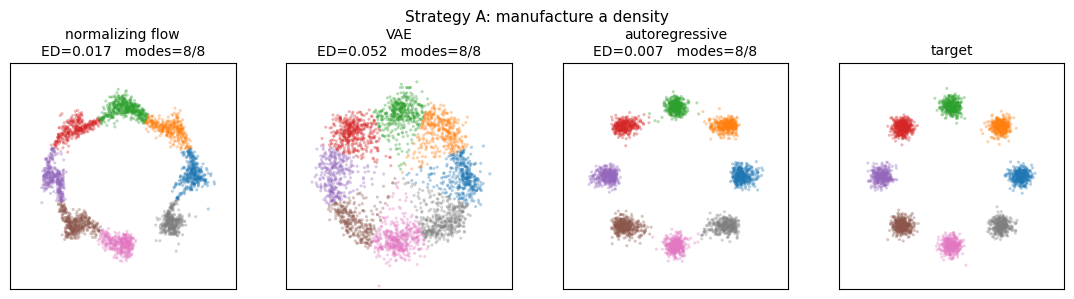

method                    ED    modes  sample steps
normalizing flow      0.0172      8/8             1
VAE                   0.0518      8/8             1
autoregressive        0.0072      8/8             2


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(11.2, 3.0))
for ax, key in zip(axes, ["normalizing flow", "VAE", "autoregressive"]):
    result = DENSITY_RUNS[key]
    title = f"{key}\nED={result['energy']:.3f}   modes={result['modes']}/8"
    plot_samples(ax, result["samples"], title, by_mode=True)
plot_samples(axes[3], DATA, "target", color="#b45309", by_mode=True)
plt.suptitle("Strategy A: manufacture a density", fontsize=11)
plt.tight_layout()
plt.show()

print(f"{'method':18s}  {'ED':>8s}  {'modes':>7s}  {'sample steps':>12s}")
for key, result in DENSITY_RUNS.items():
    print(
        f"{key:18s}  {result['energy']:8.4f}  "
        f"{result['modes']:>5d}/8  {result['sample_steps']:>12d}"
    )

All three methods make forward-KL-style pretraining possible, and all three cover the ring's modes.
Their samples expose the price of the density construction:

- the normalizing flow keeps thin connections because invertibility prevents tearing;
- the VAE softens the modes because its bound and Gaussian reconstruction favor averaging;
- the autoregressive model looks strongest here because two dimensions make sequential generation
  exceptionally cheap.

Manufacturing a density gives a principled likelihood objective, but the density is never free. The
next strategy keeps a free-form generator and instead chooses a comparison computable directly from
samples.

<div class="notebook-footer"><a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey.ipynb">Generative Modeling: A Gentle Journey with Distribution Matching</a> &middot; Chapter 5 of 21</div>